In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ==============================================================================
# BLOQUE AUTÓNOMO: RE-ENTRENAMIENTO RÁPIDO (En el Notebook 4)
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

# 1. Cargar el dataset que ya limpiamos y guardamos antes
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Preparar los mismos X e Y que usamos en el Notebook 3
col_objetivo = 'FRAUDE_IA'
X = df.drop(columns=[col_objetivo]).values
Y = df[col_objetivo].values

# 3. Entrenar el modelo (XGBoost es tan rápido que esto tomará 1 minuto)
print("🧠 Entrenando modelo de respaldo para SHAP...")
peso_fraude = np.sum(Y == 0) / np.sum(Y == 1)
modelo_xgb = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=peso_fraude, tree_method='hist', n_jobs=-1)
modelo_xgb.fit(X, Y)

# 4. Crear X_test para SHAP
_, X_test, _, _ = train_test_split(X, Y, test_size=0.2, random_state=42)

print("✅ Modelo listo para SHAP.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🧠 Entrenando modelo de respaldo para SHAP...
✅ Modelo listo para SHAP.


In [5]:
# ==============================================================================
# BLOQUE MAESTRO: ENTRENAMIENTO Y RADIOGRAFÍA SHAP (TODO EN UNO)
# ==============================================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Conectar y Cargar
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Preparar datos
col_objetivo = 'FRAUDE_IA'
X = df.drop(columns=[col_objetivo]).values
Y = df[col_objetivo].values
nombres_variables = df.drop(columns=[col_objetivo]).columns.tolist()

# 3. Entrenar el Cazador (XGBoost rápido)
print("🧠 Entrenando modelo de respaldo para SHAP...")
peso_fraude = np.sum(Y == 0) / np.sum(Y == 1)
modelo_xgb = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=peso_fraude, tree_method='hist', n_jobs=-1)
modelo_xgb.fit(X, Y)
print("✅ ¡Modelo listo!")

# 4. Calcular el Osciloscopio SHAP
print("⏳ Calculando impacto SHAP (esto puede tardar 1-2 minutos)...")
# Tomamos una muestra para que el cálculo sea rápido
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=1000, replace=False)
X_muestra = X[indices_muestra]
df_muestra_shap = pd.DataFrame(X_muestra, columns=nombres_variables)

explicador = shap.TreeExplainer(modelo_xgb)
shap_values = explicador(df_muestra_shap)

# 5. Generar Radiografía Global
print("📊 Generando Radiografía...")
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_muestra_shap, max_display=20, show=False)
plt.title("Radiografía del Fraude: Top 20 Variables Críticas (SHAP)", fontsize=16)
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

🔌 1. Preparando explicador ligero...
✅ ¡Cálculos terminados! Generando gráfica...


/tmp/ipykernel_15433/499435418.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, df_muestra_shap, max_display=15, show=False)


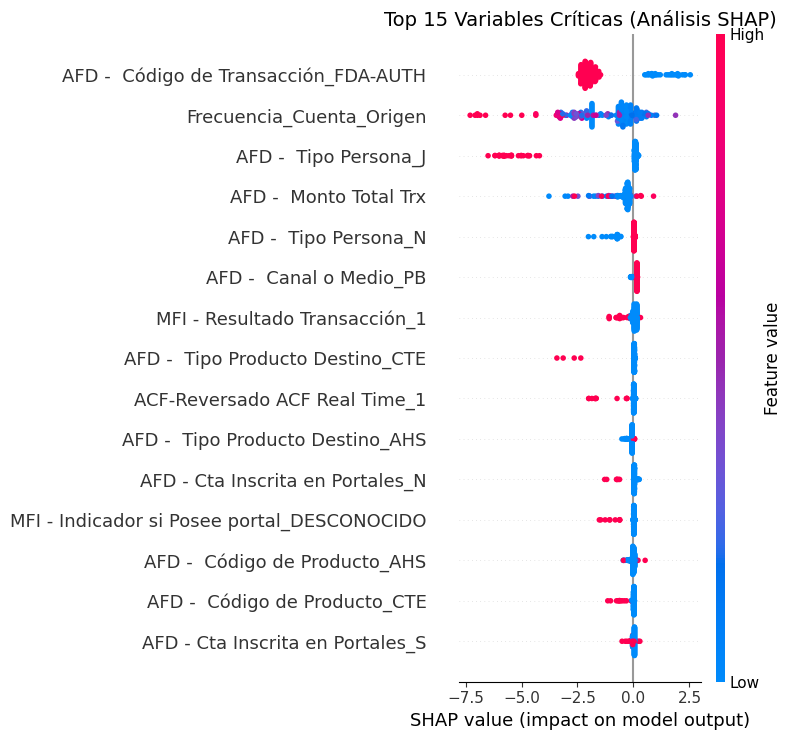

In [7]:
# ==============================================================================
# RADIOGRAFÍA SHAP - VERSIÓN FINAL Y AUTOCONTENIDA
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("🔌 1. Preparando explicador ligero...")

# 1. Recuperamos los nombres reales de las columnas directamente del DataFrame 'df'
# que ya debes tener cargado en este Notebook.
# (Excluimos la columna objetivo para que coincida con X)
col_objetivo = 'FRAUDE_IA'
nombres_variables_reales = [c for c in df.columns if c != col_objetivo]

# 2. Muestreo ultra-reducido (200 transacciones son suficientes para el reporte)
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=200, replace=False)
X_muestra = X[indices_muestra]
df_muestra_shap = pd.DataFrame(X_muestra, columns=nombres_variables_reales)

# 3. Usar 'TreeExplainer' con 'feature_perturbation="tree_path_dependent"'
explicador = shap.TreeExplainer(modelo_xgb, feature_perturbation="tree_path_dependent")
shap_values = explicador(df_muestra_shap)

print("✅ ¡Cálculos terminados! Generando gráfica...")

# 4. Generar Radiografía Global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, df_muestra_shap, max_display=15, show=False)
plt.title("Top 15 Variables Críticas (Análisis SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
import os
# Ruta donde esperamos que esté
ruta = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/'

# Listamos qué hay dentro
if os.path.exists(ruta):
    print("✅ Carpeta encontrada. Contenido:")
    print(os.listdir(ruta))
else:
    print("❌ La carpeta NO existe. Revisa la ruta en la barra lateral izquierda.")

✅ Carpeta encontrada. Contenido:
['Data 378(in).csv', 'datos_fraude_anon.csv', 'Exploracion_Datos', 'entrega-2.gdoc', 'reporte_perfilamiento.html', 'universidad.xlsx', 'universidad.csv', 'reporte_fraude_maestria_FULL.html', 'dataset_final_para_IA.csv', 'Untitled0.ipynb', 'dataset_listo_para_IA.csv', 'home', 'manual-instalacion.pdf', 'manual-instalacion.docx', 'Microproyecto1 Tercera Entrega - Detección del fraude-2.docx', 'Fraude_propuesta_proyecto.docx', 'Fraude_propuesta_proyecto_V2.docx', 'Video Microproyecto.mp4', '01_Exploracion_Curaduria_Fraude', '04_Explicabilidad_SHAP.ipynb', '05_Redes_Neuronales_Grafos_GNN.ipynb', '06_Capa_Optimización_DRL.ipynb', '07_Torneo_Modelos', '03_Modelo_Supervisado_XGBoost', 'Universidad_1.xlsx', 'Universidad_2.xlsx', 'Copia de 01_Exploracion_Curaduria_Fraude', 'dataset_limpio_IA.csv', '02_Modelo_Autoencoder', 'Copia de 02_Modelo_Autoencoder', 'Copia de 03_Modelo_Supervisado_XGBoost', 'Copia de 04_Explicabilidad_SHAP.ipynb']


In [7]:
import joblib
import xgboost as xgb
import pandas as pd

# Cargar el modelo guardado
modelo_xgb = joblib.load('/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/modelo_cazador_xgb.pkl')

# Cargar los datos de prueba (X_test)
# Para esto, tendrías que haber guardado X_test en el notebook anterior con np.save
X_test = np.load('/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/X_test.npy')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/modelo_cazador_xgb.pkl'

In [6]:
# ==============================================================================
# PASO FINAL: RADIOGRAFÍA CON SHAP (Corregido)
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("🔌 1. Conectando el 'Osciloscopio' SHAP al modelo XGBoost...")

# DEFINICIÓN EXPLÍCITA (Para evitar el NameError)
col_objetivo = 'FRAUDE_IA'
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'

# 1. Recuperar los nombres de las columnas
df_nombres = pd.read_csv(ruta_datos, nrows=1)
nombres_variables = [c for c in df_nombres.columns if c != col_objetivo]

# 2. Muestreo Inteligente
np.random.seed(42)
indices_muestra = np.random.choice(X_test.shape[0], size=1000, replace=False)
X_test_muestra = X_test[indices_muestra]
df_muestra_shap = pd.DataFrame(X_test_muestra, columns=nombres_variables)

# 3. Calculamos los valores SHAP
print("⏳ 2. Calculando el impacto de las 169 variables (esto puede tardar)...")
explicador = shap.TreeExplainer(modelo_xgb)
shap_values = explicador(df_muestra_shap)
print("✅ ¡Cálculos terminados!")

# 4. Radiografía Global
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, df_muestra_shap, max_display=20, show=False)
plt.title("Radiografía del Fraude: Top 20 Variables Críticas (SHAP)", fontsize=16)
plt.tight_layout()
plt.show()

🔌 1. Conectando el 'Osciloscopio' SHAP al modelo XGBoost...


NameError: name 'X_test' is not defined

In [5]:
# ==============================================================================
# PASO FINAL: EXPLICABILIDAD DEL MODELO CON SHAP (RADIOGRAFÍA DEL FRAUDE)
# ==============================================================================
!pip install shap -q
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("🔌 1. Conectando el 'Osciloscopio' SHAP al modelo XGBoost...")

# 1. Recuperar los nombres de las columnas (quitando FRAUDE_IA)
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
# Leemos solo 1 fila para sacar los nombres de las 169 columnas rápido
df_nombres = pd.read_csv(ruta_datos, nrows=1)
nombres_variables = df_nombres.drop(columns=[col_objetivo]).columns.tolist()

# 2. Muestreo Inteligente para SHAP (Para no quemar la RAM)
# SHAP es matemáticamente muy pesado. Tomaremos 1,000 transacciones de prueba al azar.
np.random.seed(42)
indices_muestra = np.random.choice(X_test.shape[0], size=1000, replace=False)

X_test_muestra = X_test[indices_muestra]
df_muestra_shap = pd.DataFrame(X_test_muestra, columns=nombres_variables)

# 3. Calculamos los valores SHAP
print("⏳ 2. Calculando el impacto de las 169 variables (Esto puede tardar 1 o 2 minutos)...")
explicador = shap.TreeExplainer(modelo_xgb)
shap_values = explicador(df_muestra_shap)
print("✅ ¡Cálculos terminados!")

# ==============================================================================
# VISUALIZACIÓN DEL ADN DEL FRAUDE
# ==============================================================================
print("\n📊 3. Generando la Radiografía Global de SHAP...")

plt.figure(figsize=(12, 10))
# summary_plot nos muestra el top 20 de variables más importantes
shap.summary_plot(shap_values, df_muestra_shap, max_display=20, show=False)
plt.title("Radiografía del Fraude en Big Data: Top 20 Variables Críticas (SHAP)", fontsize=16)
plt.tight_layout()
plt.show()

🔌 1. Conectando el 'Osciloscopio' SHAP al modelo XGBoost...


NameError: name 'col_objetivo' is not defined

In [ ]:
# ==============================================================================
# PASO 1: INSTALACIÓN DE LA HERRAMIENTA DE "OSCILOSCOPIO" (SHAP)
# ==============================================================================
!pip install shap xgboost -q
print("✅ Librería SHAP instalada correctamente.")

import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Conectar al Drive
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# PASO 2: CARGA RÁPIDA Y REENTRENAMIENTO DEL MODELO (PISO 2)
# ==============================================================================
print("\n🚀 1. Cargando datos y reconectando el modelo XGBoost...")
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

col_objetivo =[c for c in df.columns if 'FRAUDE_IA' in c][0]
Y = df[col_objetivo].values
# Guardamos los NOMBRES de las variables, esto es vital para que SHAP nos hable en español y no en números
nombres_variables = df.drop(columns=[col_objetivo]).columns.tolist()
X = df.drop(columns=[col_objetivo]).values

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

peso_fraude = np.sum(y_train == 0) / np.sum(y_train == 1)

# Recreamos a nuestro "Cazador" rápidamente
modelo_xgb = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=peso_fraude, tree_method='hist', random_state=42, n_jobs=-1
)
modelo_xgb.fit(X_train, y_train)
print("✅ ¡Modelo listo y calibrado para la auditoría!")

✅ Librería SHAP instalada correctamente.
Mounted at /content/drive

🚀 1. Cargando datos y reconectando el modelo XGBoost...
✅ ¡Modelo listo y calibrado para la auditoría!


🔌 1. Conectando SHAP al modelo XGBoost (Calculando el peso de cada variable)...
✅ ¡Cálculos SHAP terminados!

📊 2. Generando el reporte de Impacto Global (Summary Plot)...


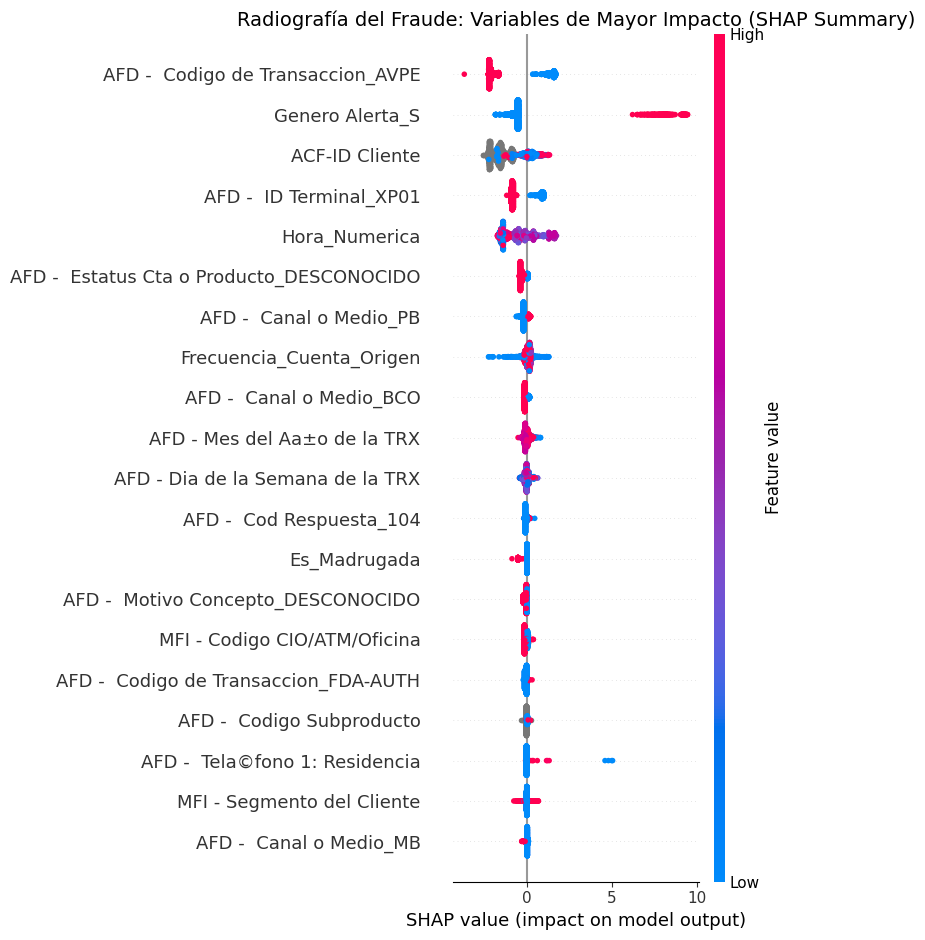

In [ ]:
# ==============================================================================
# PASO 3: CONECTAR EL "OSCILOSCOPIO" SHAP AL MODELO
# ==============================================================================
import matplotlib.pyplot as plt

print("🔌 1. Conectando SHAP al modelo XGBoost (Calculando el peso de cada variable)...")

# Para no quemar la RAM ni tardar horas, tomamos una muestra de 2000 transacciones
X_test_muestra = X_test[:2000]
y_test_muestra = y_test[:2000]

# Convertimos la matriz numérica a DataFrame de Pandas para que los gráficos tengan nombres legibles
df_muestra = pd.DataFrame(X_test_muestra, columns=nombres_variables)

# Creamos el Explicador (Nuestro Analizador de Señales)
explicador = shap.TreeExplainer(modelo_xgb)

# Calculamos los Valores SHAP (Los 'milivoltios' de culpa para cada decisión)
# Esto puede tardar entre 10 y 30 segundos
shap_values = explicador(df_muestra)
print("✅ ¡Cálculos SHAP terminados!")

# ==============================================================================
# PASO 4: AUDITORÍA GLOBAL (¿Qué variables mira el algoritmo a nivel general?)
# ==============================================================================
print("\n📊 2. Generando el reporte de Impacto Global (Summary Plot)...")

plt.figure(figsize=(10, 8))
# El summary_plot muestra qué variables empujan la decisión hacia "Fraude" (Derecha) o "Normal" (Izquierda)
shap.summary_plot(shap_values, df_muestra, show=False)
plt.title("Radiografía del Fraude: Variables de Mayor Impacto (SHAP Summary)", fontsize=14)
plt.tight_layout()
plt.show()